In [1]:
import pandas as pd
import numpy as np


In [2]:
# importing dataset
df = pd.read_csv(r"C:\Users\ginaa\OneDrive\Desktop\Portfolio Projects\Monthly_Provisional_Counts_of_Deaths_by_Select_Causes,_2020-2023_20260319 - Copy.csv")
df.head()

,Data As Of,Start Date,End Date,Jurisdiction of Occurrence,Year,Month,All Cause,Natural Cause,Septicemia,Malignant Neoplasms,...,Intentional Self-Harm (Suicide),Assault (Homicide),Drug Overdose,COVID-19 (Multiple Cause of Death),COVID-19 (Underlying Cause of Death),flag_accid,flag_mva,flag_suic,flag_homic,flag_drugod
0,09/27/2023,01/01/2020,01/31/2020,United States,2020,1,"264,681","242,914","3,687","52,635",...,"4,040","1,708","6,547",6,4,NaN,NaN,NaN,NaN,NaN
1,09/27/2023,02/01/2020,02/29/2020,United States,2020,2,"244,966","224,343","3,324","48,764",...,"3,672","1,471","6,435",25,20,NaN,NaN,NaN,NaN,NaN
2,09/27/2023,03/01/2020,03/31/2020,United States,2020,3,"269,806","247,634","3,669","51,640",...,"3,952","1,693","7,268","7,175","6,785",NaN,NaN,NaN,NaN,NaN
3,09/27/2023,04/01/2020,04/30/2020,United States,2020,4,"322,424","300,780","3,366","48,773",...,"3,480","1,756","7,938","65,553","62,014",NaN,NaN,NaN,NaN,NaN
4,09/27/2023,05/01/2020,05/31/2020,United States,2020,5,"280,564","255,489","3,085","49,012",...,"3,769","2,067","9,466","38,330","35,279",NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [3]:

df.columns = (df.columns.str.replace(" ","_")) # removing the space in the title with '_'

df.columns = (df.columns.str.lower()) # coverting str to lowercase


df.head()

,data_as_of,start_date,end_date,jurisdiction_of_occurrence,year,month,all_cause,natural_cause,septicemia,malignant_neoplasms,...,intentional_self-harm_(suicide),assault_(homicide),drug_overdose,covid-19_(multiple_cause_of_death),covid-19_(underlying_cause_of_death),flag_accid,flag_mva,flag_suic,flag_homic,flag_drugod
0,09/27/2023,01/01/2020,01/31/2020,United States,2020,1,"264,681","242,914","3,687","52,635",...,"4,040","1,708","6,547",6,4,NaN,NaN,NaN,NaN,NaN
1,09/27/2023,02/01/2020,02/29/2020,United States,2020,2,"244,966","224,343","3,324","48,764",...,"3,672","1,471","6,435",25,20,NaN,NaN,NaN,NaN,NaN
2,09/27/2023,03/01/2020,03/31/2020,United States,2020,3,"269,806","247,634","3,669","51,640",...,"3,952","1,693","7,268","7,175","6,785",NaN,NaN,NaN,NaN,NaN
3,09/27/2023,04/01/2020,04/30/2020,United States,2020,4,"322,424","300,780","3,366","48,773",...,"3,480","1,756","7,938","65,553","62,014",NaN,NaN,NaN,NaN,NaN
4,09/27/2023,05/01/2020,05/31/2020,United States,2020,5,"280,564","255,489","3,085","49,012",...,"3,769","2,067","9,466","38,330","35,279",NaN,NaN,NaN,NaN,NaN


In [4]:
# to show invisible characters in the dataset

df.applymap(lambda x: repr(x)).head()

C:\Users\ginaa\AppData\Local\Temp\ipykernel_29672\2490843025.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(lambda x: repr(x)).head()


,data_as_of,start_date,end_date,jurisdiction_of_occurrence,year,month,all_cause,natural_cause,septicemia,malignant_neoplasms,...,intentional_self-harm_(suicide),assault_(homicide),drug_overdose,covid-19_(multiple_cause_of_death),covid-19_(underlying_cause_of_death),flag_accid,flag_mva,flag_suic,flag_homic,flag_drugod
0,'09/27/2023','01/01/2020','01/31/2020','United States',2020,1,"'264,681'","'242,914'","'3,687'","'52,635'",...,"'4,040'","'1,708'","'6,547'",'6','4',nan,nan,nan,nan,nan
1,'09/27/2023','02/01/2020','02/29/2020','United States',2020,2,"'244,966'","'224,343'","'3,324'","'48,764'",...,"'3,672'","'1,471'","'6,435'",'25','20',nan,nan,nan,nan,nan
2,'09/27/2023','03/01/2020','03/31/2020','United States',2020,3,"'269,806'","'247,634'","'3,669'","'51,640'",...,"'3,952'","'1,693'","'7,268'","'7,175'","'6,785'",nan,nan,nan,nan,nan
3,'09/27/2023','04/01/2020','04/30/2020','United States',2020,4,"'322,424'","'300,780'","'3,366'","'48,773'",...,"'3,480'","'1,756'","'7,938'","'65,553'","'62,014'",nan,nan,nan,nan,nan
4,'09/27/2023','05/01/2020','05/31/2020','United States',2020,5,"'280,564'","'255,489'","'3,085'","'49,012'",...,"'3,769'","'2,067'","'9,466'","'38,330'","'35,279'",nan,nan,nan,nan,nan


In [5]:
df = (df.replace(",","", regex=True) # remove commas
               .replace("'","", regex=True)    # remove quotes
)

df.head()
               

,data_as_of,start_date,end_date,jurisdiction_of_occurrence,year,month,all_cause,natural_cause,septicemia,malignant_neoplasms,...,intentional_self-harm_(suicide),assault_(homicide),drug_overdose,covid-19_(multiple_cause_of_death),covid-19_(underlying_cause_of_death),flag_accid,flag_mva,flag_suic,flag_homic,flag_drugod
0,09/27/2023,01/01/2020,01/31/2020,United States,2020,1,264681,242914,3687,52635,...,4040,1708,6547,6,4,NaN,NaN,NaN,NaN,NaN
1,09/27/2023,02/01/2020,02/29/2020,United States,2020,2,244966,224343,3324,48764,...,3672,1471,6435,25,20,NaN,NaN,NaN,NaN,NaN
2,09/27/2023,03/01/2020,03/31/2020,United States,2020,3,269806,247634,3669,51640,...,3952,1693,7268,7175,6785,NaN,NaN,NaN,NaN,NaN
3,09/27/2023,04/01/2020,04/30/2020,United States,2020,4,322424,300780,3366,48773,...,3480,1756,7938,65553,62014,NaN,NaN,NaN,NaN,NaN
4,09/27/2023,05/01/2020,05/31/2020,United States,2020,5,280564,255489,3085,49012,...,3769,2067,9466,38330,35279,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 31 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   data_as_of                                                                               45 non-null     object
 1   start_date                                                                               45 non-null     object
 2   end_date                                                                                 45 non-null     object
 3   jurisdiction_of_occurrence                                                               45 non-null     object
 4   year                                                                                     45 non-null     int64 
 5   month                                                                    

In [8]:
df.columns

Index(['data_as_of', 'start_date', 'end_date', 'jurisdiction_of_occurrence',
       'year', 'month', 'all_cause', 'natural_cause', 'septicemia',
       'malignant_neoplasms', 'diabetes_mellitus', 'alzheimer_disease',
       'influenza_and_pneumonia', 'chronic_lower_respiratory_diseases',
       'other_diseases_of_respiratory_system',
       'nephritis,_nephrotic_syndrome_and_nephrosis',
       'symptoms,_signs_and_abnormal_clinical_and_laboratory_findings,_not_elsewhere_classified',
       'diseases_of_heart', 'cerebrovascular_diseases',
       'accidents_(unintentional_injuries)', 'motor_vehicle_accidents',
       'intentional_self-harm_(suicide)', 'assault_(homicide)',
       'drug_overdose', 'covid-19_(multiple_cause_of_death)',
       'covid-19_(underlying_cause_of_death)', 'flag_accid', 'flag_mva',
       'flag_suic', 'flag_homic', 'flag_drugod'],
      dtype='object')

In [9]:
cols = ['all_cause', 'natural_cause', 'septicemia',
       'malignant_neoplasms', 'diabetes_mellitus', 'alzheimer_disease',
       'influenza_and_pneumonia', 'chronic_lower_respiratory_diseases',
       'other_diseases_of_respiratory_system',
       'nephritis,_nephrotic_syndrome_and_nephrosis',
       'symptoms,_signs_and_abnormal_clinical_and_laboratory_findings,_not_elsewhere_classified',
       'diseases_of_heart', 'cerebrovascular_diseases',
       'accidents_(unintentional_injuries)', 'motor_vehicle_accidents',
       'intentional_self-harm_(suicide)', 'assault_(homicide)',
       'drug_overdose', 'covid-19_(multiple_cause_of_death)',
       'covid-19_(underlying_cause_of_death)', 'flag_accid', 'flag_mva',
       'flag_suic', 'flag_homic', 'flag_drugod']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')


df.dtypes

data_as_of                                                                                  object
start_date                                                                                  object
end_date                                                                                    object
jurisdiction_of_occurrence                                                                  object
year                                                                                         int64
month                                                                                        int64
all_cause                                                                                    int64
natural_cause                                                                                int64
septicemia                                                                                   int64
malignant_neoplasms                                                                          int64
diabetes_m

In [10]:
df['start_date'] = pd.to_datetime(df['start_date'], format="%d/%m/%Y")

In [11]:
df['end_date'] = pd.to_datetime(df['end_date'], format="%m/%d/%Y")

In [12]:
df['month_date'] = pd.to_datetime(
    df['year'].astype(str) + "-" + df['month'].astype(str) + "-01"
)

In [13]:

df.dtypes

data_as_of                                                                                         object
start_date                                                                                 datetime64[ns]
end_date                                                                                   datetime64[ns]
jurisdiction_of_occurrence                                                                         object
year                                                                                                int64
month                                                                                               int64
all_cause                                                                                           int64
natural_cause                                                                                       int64
septicemia                                                                                          int64
malignant_neoplasms                           

In [14]:
df.head()

,data_as_of,start_date,end_date,jurisdiction_of_occurrence,year,month,all_cause,natural_cause,septicemia,malignant_neoplasms,...,assault_(homicide),drug_overdose,covid-19_(multiple_cause_of_death),covid-19_(underlying_cause_of_death),flag_accid,flag_mva,flag_suic,flag_homic,flag_drugod,month_date
0,09/27/2023,2020-01-01,2020-01-31,United States,2020,1,264681,242914,3687,52635,...,1708.0,6547.0,6,4,NaN,NaN,NaN,NaN,NaN,2020-01-01
1,09/27/2023,2020-01-02,2020-02-29,United States,2020,2,244966,224343,3324,48764,...,1471.0,6435.0,25,20,NaN,NaN,NaN,NaN,NaN,2020-02-01
2,09/27/2023,2020-01-03,2020-03-31,United States,2020,3,269806,247634,3669,51640,...,1693.0,7268.0,7175,6785,NaN,NaN,NaN,NaN,NaN,2020-03-01
3,09/27/2023,2020-01-04,2020-04-30,United States,2020,4,322424,300780,3366,48773,...,1756.0,7938.0,65553,62014,NaN,NaN,NaN,NaN,NaN,2020-04-01
4,09/27/2023,2020-01-05,2020-05-31,United States,2020,5,280564,255489,3085,49012,...,2067.0,9466.0,38330,35279,NaN,NaN,NaN,NaN,NaN,2020-05-01


In [15]:
# dropping empty columns
df = df.drop(['flag_accid', 'flag_mva','flag_suic', 'flag_homic', 'flag_drugod'], axis=1)

df.head()

,data_as_of,start_date,end_date,jurisdiction_of_occurrence,year,month,all_cause,natural_cause,septicemia,malignant_neoplasms,...,diseases_of_heart,cerebrovascular_diseases,accidents_(unintentional_injuries),motor_vehicle_accidents,intentional_self-harm_(suicide),assault_(homicide),drug_overdose,covid-19_(multiple_cause_of_death),covid-19_(underlying_cause_of_death),month_date
0,09/27/2023,2020-01-01,2020-01-31,United States,2020,1,264681,242914,3687,52635,...,60896,14113,15012.0,2914.0,4040.0,1708.0,6547.0,6,4,2020-01-01
1,09/27/2023,2020-01-02,2020-02-29,United States,2020,2,244966,224343,3324,48764,...,56851,12818,14497.0,2910.0,3672.0,1471.0,6435.0,25,20,2020-02-01
2,09/27/2023,2020-01-03,2020-03-31,United States,2020,3,269806,247634,3669,51640,...,60229,13742,15444.0,2874.0,3952.0,1693.0,7268.0,7175,6785,2020-03-01
3,09/27/2023,2020-01-04,2020-04-30,United States,2020,4,322424,300780,3366,48773,...,62285,13420,15493.0,2569.0,3480.0,1756.0,7938.0,65553,62014,2020-04-01
4,09/27/2023,2020-01-05,2020-05-31,United States,2020,5,280564,255489,3085,49012,...,56561,12776,18205.0,3365.0,3769.0,2067.0,9466.0,38330,35279,2020-05-01


In [16]:
# replacing NAN values
nan_data = ["accidents_(unintentional_injuries)", "motor_vehicle_accidents", "intentional_self-harm_(suicide)", "assault_(homicide)", "drug_overdose"]

df[nan_data] = df[nan_data].fillna(df[nan_data].mean())

df.head()

,data_as_of,start_date,end_date,jurisdiction_of_occurrence,year,month,all_cause,natural_cause,septicemia,malignant_neoplasms,...,diseases_of_heart,cerebrovascular_diseases,accidents_(unintentional_injuries),motor_vehicle_accidents,intentional_self-harm_(suicide),assault_(homicide),drug_overdose,covid-19_(multiple_cause_of_death),covid-19_(underlying_cause_of_death),month_date
0,09/27/2023,2020-01-01,2020-01-31,United States,2020,1,264681,242914,3687,52635,...,60896,14113,15012.0,2914.0,4040.0,1708.0,6547.0,6,4,2020-01-01
1,09/27/2023,2020-01-02,2020-02-29,United States,2020,2,244966,224343,3324,48764,...,56851,12818,14497.0,2910.0,3672.0,1471.0,6435.0,25,20,2020-02-01
2,09/27/2023,2020-01-03,2020-03-31,United States,2020,3,269806,247634,3669,51640,...,60229,13742,15444.0,2874.0,3952.0,1693.0,7268.0,7175,6785,2020-03-01
3,09/27/2023,2020-01-04,2020-04-30,United States,2020,4,322424,300780,3366,48773,...,62285,13420,15493.0,2569.0,3480.0,1756.0,7938.0,65553,62014,2020-04-01
4,09/27/2023,2020-01-05,2020-05-31,United States,2020,5,280564,255489,3085,49012,...,56561,12776,18205.0,3365.0,3769.0,2067.0,9466.0,38330,35279,2020-05-01


In [ ]:
df.isnull().values.any() # to check for null values

np.False_

In [18]:
df.to_csv('cleaned_data.csv', index=False)

In [19]:
new_data_df = {'infectious_causes':'septicemia',
       'cance':'malignant_neoplasms', 
       'metabolic_disease': 'diabetes_mellitus', 
       'neurological_causes': 'alzheimer_disease',
       'infectious_causes': 'influenza_and_pneumonia', 
       'respiratory_causes': 'chronic_lower_respiratory_diseases',
       'respiratory_causes': 'other_diseases_of_respiratory_system',
       'organ_related_diseases': 'nephritis,_nephrotic_syndrome_and_nephrosis',
       'other_causes': 'symptoms,_signs_and_abnormal_clinical_and_laboratory_findings,_not_elsewhere_classified',
       'organ_related_diseases': 'diseases_of_heart', 
       'neurological_causes': 'cerebrovascular_diseases',
       'external_causes': 'accidents_(unintentional_injuries)', 
       'external_causes':'motor_vehicle_accidents',
       'external_causes': 'intentional_self-harm_(suicide)', 
       'external_causes': 'assault_(homicide)',
       'external_causes': 'drug_overdose', 
       'infectious_causes': 'covid-19_(multiple_cause_of_death)',
       'infectious_causes': 'covid-19_(underlying_cause_of_death)'
}

# Exploratory Data Analysis

In [20]:
pip install dash

Note: you may need to restart the kernel to use updated packages.


In [21]:
# importing libraries
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

import plotly.express as px

app = dash.Dash(__name__)

In [25]:
new_features = ['septicemia','natural_cause',
       'malignant_neoplasms', 'diabetes_mellitus', 'alzheimer_disease',
       'influenza_and_pneumonia', 'chronic_lower_respiratory_diseases',
       'other_diseases_of_respiratory_system',
       'nephritis,_nephrotic_syndrome_and_nephrosis',
       'symptoms,_signs_and_abnormal_clinical_and_laboratory_findings,_not_elsewhere_classified',
       'diseases_of_heart', 'cerebrovascular_diseases',
       'accidents_(unintentional_injuries)', 'motor_vehicle_accidents',
       'intentional_self-harm_(suicide)', 'assault_(homicide)',
       'drug_overdose', 'covid-19_(multiple_cause_of_death)',
       'covid-19_(underlying_cause_of_death)']

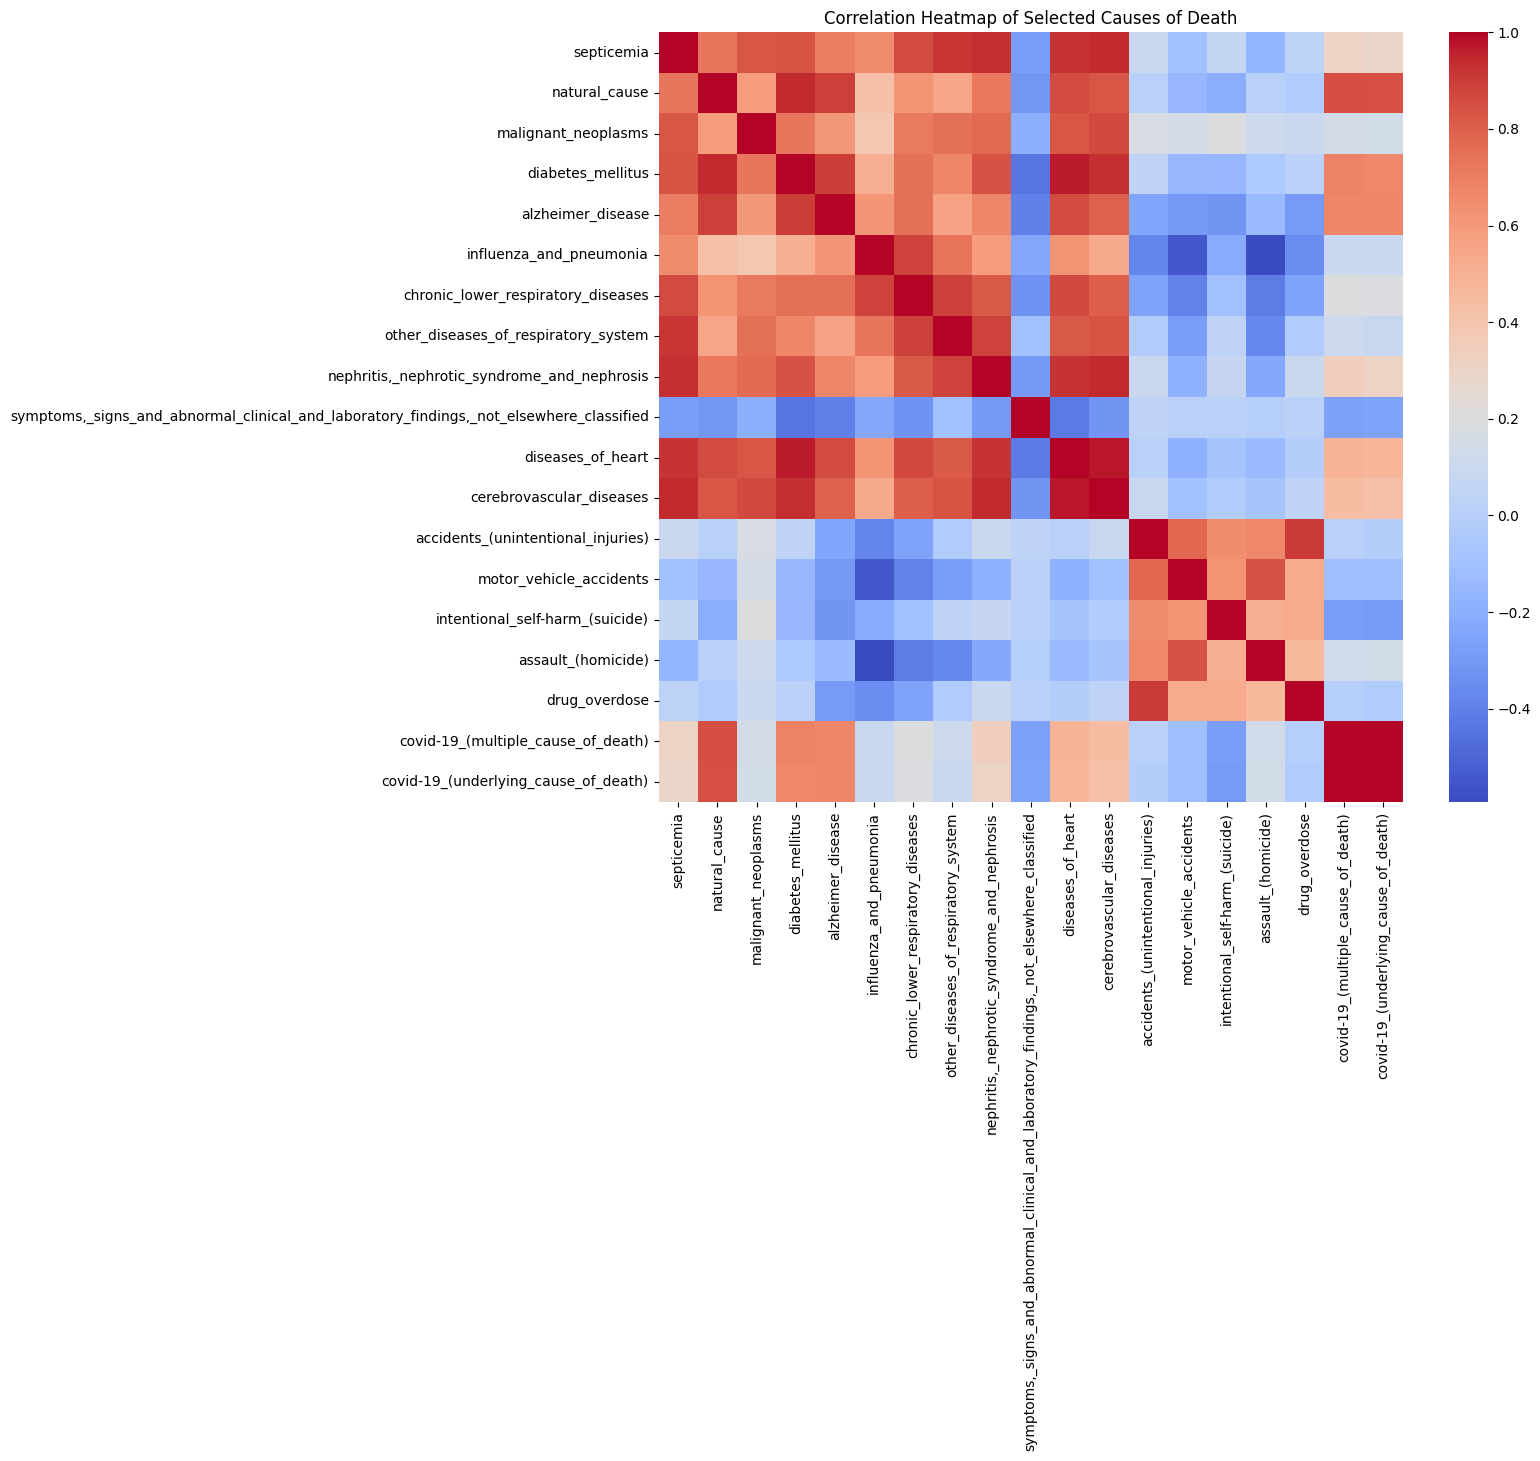

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# select only the columns you want
df_subset = df[new_features]

# compute correlation matrix
corr = df_subset.corr()

# plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Selected Causes of Death")
plt.show()